Исходные данные (первые 5 строк):
        x       y
0  0.5966  6.9824
1  1.5259  5.3286
2  1.6426  5.2720
3  1.7729  7.8449
4  1.9611  5.1646

Общее количество наблюдений: 50



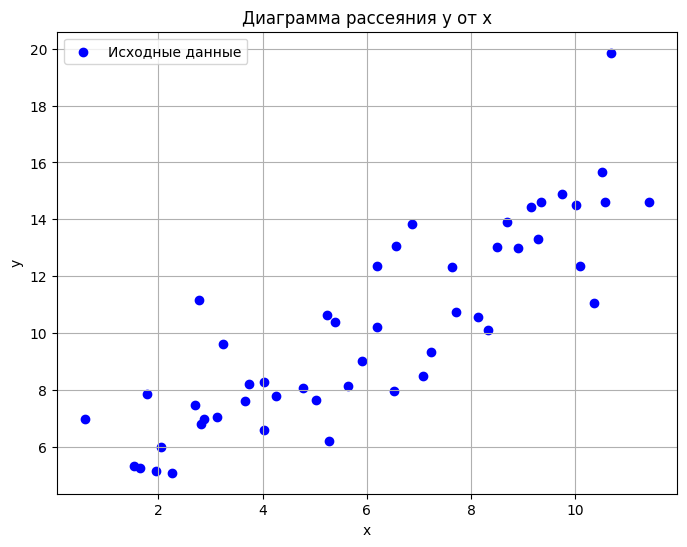

Среднее x: 6.0420
Среднее y: 10.1603
Sxx: 446.2544
Sxy: 429.0738
Оценка β1 (наклон): 0.9615
Оценка β0 (свободный член): 4.3509
Уравнение регрессии: ŷ = 4.3509 + 0.9615 * x

Таблица прогнозных значений и остатков (первые 10 строк):
        x        y         ŷ         e         e²
0  0.5966   6.9824  4.924505  2.057895   4.234930
1  1.5259   5.3286  5.818028 -0.489428   0.239539
2  1.6426   5.2720  5.930235 -0.658235   0.433273
3  1.7729   7.8449  6.055518  1.789382   3.201887
4  1.9611   5.1646  6.236473 -1.071873   1.148911
5  2.0533   5.9850  6.325123 -0.340123   0.115684
6  2.2539   5.0892  6.518000 -1.428800   2.041469
7  2.7119   7.4560  6.958367  0.497633   0.247639
8  2.7864  11.1629  7.029999  4.132901  17.080873
9  2.8279   6.7935  7.069901 -0.276401   0.076398

Остаточная сумма квадратов RSS: 151.2872
Оценка дисперсии ошибки s²: 3.1518
Остаточное стандартное отклонение s: 1.7753

Критическое значение t (α=0.05, df=48): 2.0106
Стандартная ошибка SE(β0): 0.5665
Стандартная ошиб

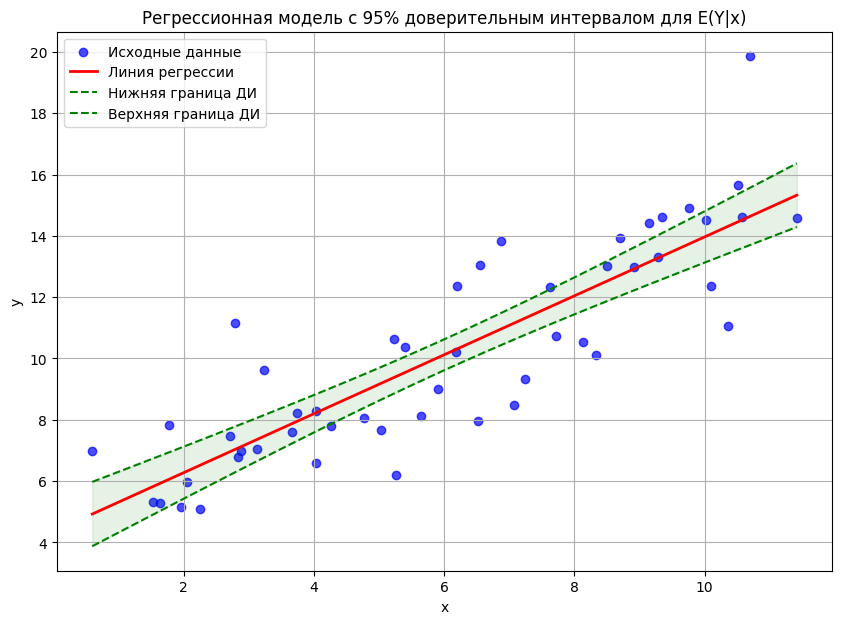


Общая сумма квадратов TSS: 563.8418
Коэффициент детерминации R²: 0.7317

ВЫВОДЫ
1. Полученное уравнение регрессии: ŷ = 4.3509 + 0.9615·x
2. Коэффициент β1 = 0.9615 > 0, следовательно, зависимость между x и y положительная.
3. 95% доверительный интервал для β1: [0.7925, 1.1305]. Ноль не попадает в этот интервал.
4. Линейная зависимость статистически значима на уровне 5% (так как доверительный интервал для β1 не содержит нуля).
5. Доверительный интервал для функции регрессии наиболее узкий вблизи среднего значения x (примерно в центре графика) и расширяется к краям.
6. Коэффициент детерминации R² = 0.7317 означает, что 73.17% изменчивости y объясняется построенной линейной моделью. По графику видно, что точки достаточно хорошо следуют за прямой, но присутствует заметный разброс, что согласуется с R² около 0.73.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# ==============================
# 1. Загрузка данных
# ==============================
data = pd.read_csv('variant_5_data.csv')
# Удалим столбец 'i', если он есть
if 'i' in data.columns:
    data = data.drop(columns=['i'])
n = len(data)
print("Исходные данные (первые 5 строк):")
print(data.head())
print(f"\nОбщее количество наблюдений: {n}\n")

x = data['x'].values
y = data['y'].values

# ==============================
# 2. Диаграмма рассеяния
# ==============================
plt.figure(figsize=(8, 6))
plt.scatter(x, y, color='blue', label='Исходные данные')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Диаграмма рассеяния y от x')
plt.grid(True)
plt.legend()
plt.show()

# Предварительный вывод: визуально можно предположить положительную линейную зависимость.

# ==============================
# 3. Оценка коэффициентов регрессии
# ==============================
x_bar = np.mean(x)
y_bar = np.mean(y)
Sxx = np.sum((x - x_bar)**2)
Sxy = np.sum((x - x_bar)*(y - y_bar))

beta1 = Sxy / Sxx
beta0 = y_bar - beta1 * x_bar

print(f"Среднее x: {x_bar:.4f}")
print(f"Среднее y: {y_bar:.4f}")
print(f"Sxx: {Sxx:.4f}")
print(f"Sxy: {Sxy:.4f}")
print(f"Оценка β1 (наклон): {beta1:.4f}")
print(f"Оценка β0 (свободный член): {beta0:.4f}")
print(f"Уравнение регрессии: ŷ = {beta0:.4f} + {beta1:.4f} * x")

# ==============================
# 4. Прогнозные значения и остатки
# ==============================
y_hat = beta0 + beta1 * x
residuals = y - y_hat
residuals_sq = residuals**2
RSS = np.sum(residuals_sq)

# Таблица с результатами
results_table = pd.DataFrame({
    'x': x,
    'y': y,
    'ŷ': y_hat,
    'e': residuals,
    'e²': residuals_sq
})
print("\nТаблица прогнозных значений и остатков (первые 10 строк):")
print(results_table.head(10))

# ==============================
# 5. Оценка дисперсии ошибки
# ==============================
s2 = RSS / (n - 2)   # несмещённая оценка дисперсии
s = np.sqrt(s2)      # остаточное стандартное отклонение

print(f"\nОстаточная сумма квадратов RSS: {RSS:.4f}")
print(f"Оценка дисперсии ошибки s²: {s2:.4f}")
print(f"Остаточное стандартное отклонение s: {s:.4f}")

# ==============================
# 6. Доверительные интервалы для коэффициентов
# ==============================
alpha = 0.05
t_crit = stats.t.ppf(1 - alpha/2, df=n-2)

# Стандартные ошибки
SE_beta1 = s / np.sqrt(Sxx)
SE_beta0 = s * np.sqrt(1/n + x_bar**2 / Sxx)

# Доверительные интервалы
CI_beta0 = (beta0 - t_crit * SE_beta0, beta0 + t_crit * SE_beta0)
CI_beta1 = (beta1 - t_crit * SE_beta1, beta1 + t_crit * SE_beta1)

print(f"\nКритическое значение t (α=0.05, df={n-2}): {t_crit:.4f}")
print(f"Стандартная ошибка SE(β0): {SE_beta0:.4f}")
print(f"Стандартная ошибка SE(β1): {SE_beta1:.4f}")
print(f"95% доверительный интервал для β0: [{CI_beta0[0]:.4f}, {CI_beta0[1]:.4f}]")
print(f"95% доверительный интервал для β1: [{CI_beta1[0]:.4f}, {CI_beta1[1]:.4f}]")

if CI_beta1[0] > 0 or CI_beta1[1] < 0:
    print("Ноль не попадает в ДИ для β1 → линейная зависимость статистически значима.")
else:
    print("Ноль попадает в ДИ для β1 → линейная зависимость незначима.")

# ==============================
# 7. Доверительный интервал для функции регрессии
# ==============================
# Создадим сетку x0 в диапазоне от min(x) до max(x)
x_grid = np.linspace(min(x), max(x), 100)
y_hat_grid = beta0 + beta1 * x_grid
# Стандартная ошибка средней функции регрессии
SE_yhat = s * np.sqrt(1/n + (x_grid - x_bar)**2 / Sxx)
# Границы интервала
lower_bound = y_hat_grid - t_crit * SE_yhat
upper_bound = y_hat_grid + t_crit * SE_yhat

# Построение графика
plt.figure(figsize=(10, 7))
plt.scatter(x, y, color='blue', label='Исходные данные', alpha=0.7)
plt.plot(x_grid, y_hat_grid, color='red', linewidth=2, label='Линия регрессии')
plt.plot(x_grid, lower_bound, color='green', linestyle='--', label='Нижняя граница ДИ')
plt.plot(x_grid, upper_bound, color='green', linestyle='--', label='Верхняя граница ДИ')
plt.fill_between(x_grid, lower_bound, upper_bound, color='green', alpha=0.1)
plt.xlabel('x')
plt.ylabel('y')
plt.title('Регрессионная модель с 95% доверительным интервалом для E(Y|x)')
plt.grid(True)
plt.legend()
plt.show()

# ==============================
# 8. Коэффициент детерминации R²
# ==============================
TSS = np.sum((y - y_bar)**2)
R2 = 1 - RSS/TSS
print(f"\nОбщая сумма квадратов TSS: {TSS:.4f}")
print(f"Коэффициент детерминации R²: {R2:.4f}")

# ==============================
# 9. Выводы
# ==============================
print("\n" + "="*60)
print("ВЫВОДЫ")
print("="*60)
print(f"1. Полученное уравнение регрессии: ŷ = {beta0:.4f} + {beta1:.4f}·x")
print(f"2. Коэффициент β1 = {beta1:.4f} > 0, следовательно, зависимость между x и y положительная.")
print(f"3. 95% доверительный интервал для β1: [{CI_beta1[0]:.4f}, {CI_beta1[1]:.4f}]. Ноль {'не попадает' if CI_beta1[0] > 0 or CI_beta1[1] < 0 else 'попадает'} в этот интервал.")
print(f"4. Линейная зависимость статистически значима на уровне 5% (так как доверительный интервал для β1 не содержит нуля).")
print("5. Доверительный интервал для функции регрессии наиболее узкий вблизи среднего значения x (примерно в центре графика) и расширяется к краям.")
print(f"6. Коэффициент детерминации R² = {R2:.4f} означает, что {R2*100:.2f}% изменчивости y объясняется построенной линейной моделью. По графику видно, что точки достаточно хорошо следуют за прямой, но присутствует заметный разброс, что согласуется с R² около {R2:.2f}.")